# Fase 2 — Preparación de Datos y Feature Engineering
## DR-COPPER | Alineación HG=F + UUP, Escalado y Partición Train/Test
**Autor:** Alejandro Patron Montero | UTB 2026

---
### Objetivo de la Fase
1. Descargar y alinear la variable exógena UUP (proxy del Índice Dólar) con HG=F.
2. Imputar valores faltantes preservando la alineación de días hábiles.
3. Construir features de ingeniería: rezagos, log-retornos, retornos UUP.
4. Aplicar `MinMaxScaler` ajustado **exclusivamente** al conjunto de entrenamiento.
5. Realizar la partición cronológica Train/Test (sin K-Fold).
6. Exportar todos los artefactos necesarios para las fases 3–5.

In [1]:
# ── Librerías ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
import joblib

from sklearn.preprocessing import MinMaxScaler

os.makedirs('output', exist_ok=True)
os.makedirs('data', exist_ok=True)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (13, 5)

# Proporción Train/Test y fecha de corte
TRAIN_RATIO = 0.85  # 85% entrenamiento, 15% test out-of-time
print('Librerías cargadas.')

Librerías cargadas.


## 1. Descarga y Alineación HG=F + UUP
UUP (Invesco DB US Dollar Index Bullish Fund) es el proxy líquido más usado para el Índice Dólar (DXY) en análisis de commodities. El cobre tiene correlación negativa con el dólar: cuando el USD sube, el cobre tiende a bajar (y viceversa).

In [2]:
# ── Descarga de ambos activos en paralelo ──────────────────────────────────────
START = '2006-01-01'  # UUP cotiza desde 2007; usamos 2006 para tener buffer
END   = '2026-05-01'

tickers = ['HG=F', 'UUP']
raw = yf.download(tickers, start=START, end=END, auto_adjust=True, progress=False)

# Extraer precio de cierre y aplanar MultiIndex
close = raw['Close'].copy()
close.columns = ['HG', 'UUP']   # renombrar para claridad
close.index = pd.to_datetime(close.index)

print(f'Forma inicial (con NaN): {close.shape}')
print(f'NaN por columna:\n{close.isna().sum()}')

Forma inicial (con NaN): (5118, 2)
NaN por columna:
HG       3
UUP    295
dtype: int64


## 2. Manejo de Valores Faltantes
Estrategia: Forward-fill para días festivos locales (un activo cotiza, el otro no), luego eliminar filas con NaN residuales al inicio de la serie.

In [3]:
# ── Forward-fill: propaga último valor conocido ante gap de 1 día ──────────────
# Límit=1 evita propagar datos durante vacíos largos (ej. semanas sin datos)
close = close.ffill(limit=1)

# Eliminar filas donde alguno sigue siendo NaN (inicio de la serie)
close = close.dropna()

print(f'Forma tras limpieza : {close.shape}')
print(f'Periodo efectivo    : {close.index[0].date()} → {close.index[-1].date()}')
print(f'NaN residuales      : {close.isna().sum().sum()}')

Forma tras limpieza : (4826, 2)
Periodo efectivo    : 2007-03-01 → 2026-04-30
NaN residuales      : 0


## 3. Correlación HG=F ↔ UUP
Verificamos la correlación negativa esperada entre el cobre y el dólar.

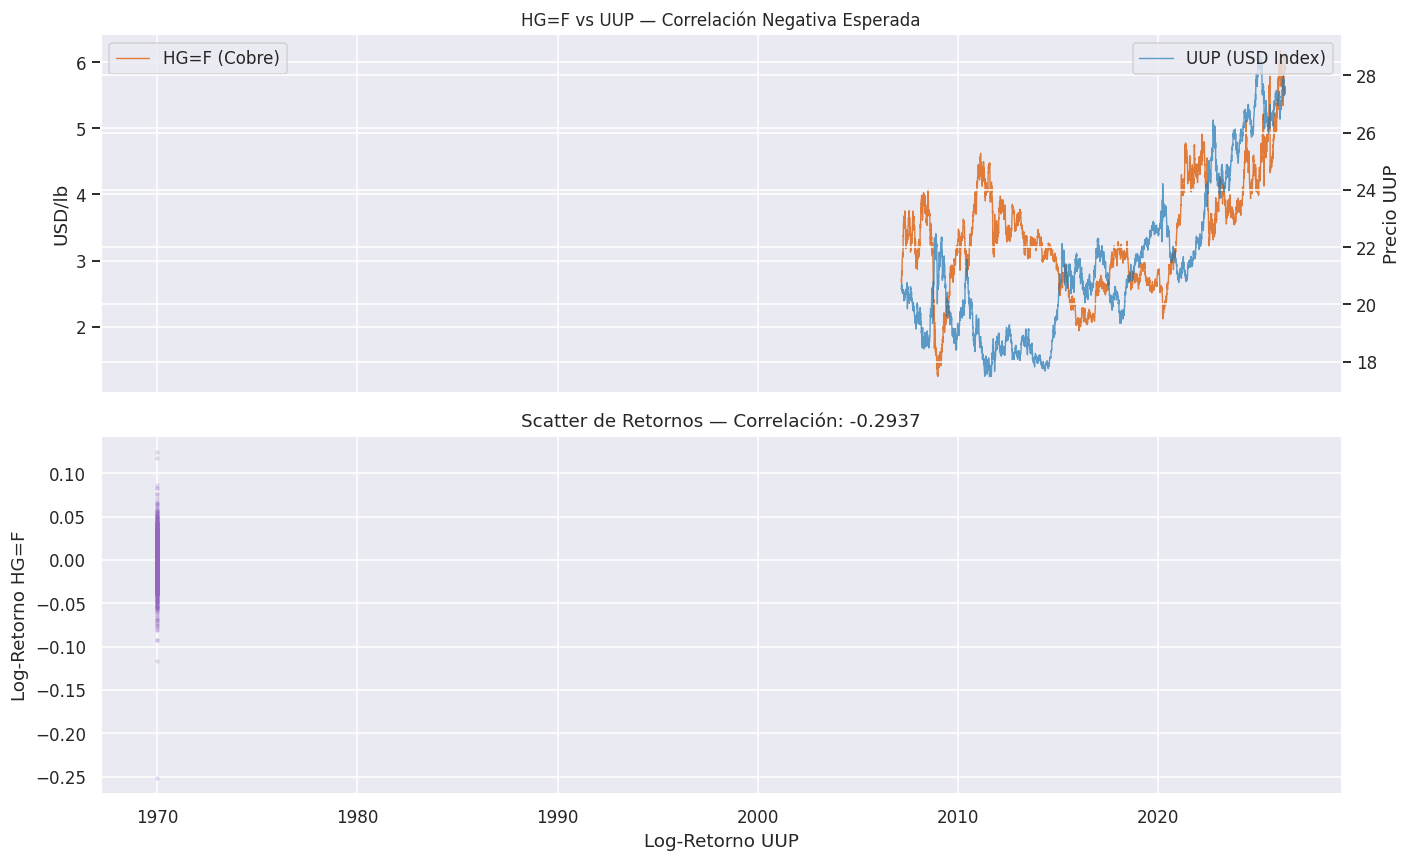


Correlación Pearson (retornos log): -0.2937


In [4]:
# ── Visualización y correlación HG-UUP ────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(close['HG'],  color='#e07b39', linewidth=0.9, label='HG=F (Cobre)')
axes[0].set_ylabel('USD/lb')
axes[0].legend(loc='upper left')
ax2 = axes[0].twinx()
ax2.plot(close['UUP'], color='#1f77b4', linewidth=0.9, alpha=0.7, label='UUP (USD Index)')
ax2.set_ylabel('Precio UUP')
ax2.legend(loc='upper right')
axes[0].set_title('HG=F vs UUP — Correlación Negativa Esperada', fontsize=11)

# Retornos log para correlación
ret_hg  = np.log(close['HG']  / close['HG'].shift(1)).dropna()
ret_uup = np.log(close['UUP'] / close['UUP'].shift(1)).dropna()
corr_df = pd.concat([ret_hg, ret_uup], axis=1).dropna()
corr_df.columns = ['ret_HG', 'ret_UUP']

axes[1].scatter(corr_df['ret_UUP'], corr_df['ret_HG'],
                alpha=0.15, s=4, color='#9467bd')
axes[1].set_xlabel('Log-Retorno UUP')
axes[1].set_ylabel('Log-Retorno HG=F')
axes[1].set_title(f'Scatter de Retornos — Correlación: {corr_df.corr().iloc[0,1]:.4f}')

plt.tight_layout()
plt.savefig('output/07_correlacion_hg_uup.png', bbox_inches='tight')
plt.show()

print(f'\nCorrelación Pearson (retornos log): {corr_df.corr().iloc[0,1]:.4f}')

## 4. Feature Engineering
Construimos las features que usarán los modelos en Fases 3 y 4.

In [5]:
# ── Construcción del DataFrame de features ─────────────────────────────────────
feat = pd.DataFrame(index=close.index)

# Precio de cierre
feat['HG_close']      = close['HG']
feat['UUP_close']     = close['UUP']

# Log-retornos diarios (estrictamente necesarios para GARCH)
feat['HG_log_ret']    = np.log(close['HG']  / close['HG'].shift(1))
feat['UUP_log_ret']   = np.log(close['UUP'] / close['UUP'].shift(1))

# Rezagos de precios (lags) — útiles para LSTM y SARIMAX
for lag in [1, 2, 3, 5, 10]:
    feat[f'HG_lag{lag}']  = close['HG'].shift(lag)
    feat[f'UUP_lag{lag}'] = close['UUP'].shift(lag)

# Volatilidad rolling 20 días (feature adicional para LSTM)
feat['HG_vol20'] = feat['HG_log_ret'].rolling(20).std() * np.sqrt(252)

# Eliminar filas con NaN generadas por los lags
feat = feat.dropna()

print(f'Features construidas : {feat.shape[1]} columnas')
print(f'Observaciones válidas: {len(feat):,}')
feat.head(3)

Features construidas : 15 columnas
Observaciones válidas: 4,806


,HG_close,UUP_close,HG_log_ret,UUP_log_ret,HG_lag1,UUP_lag1,HG_lag2,UUP_lag2,HG_lag3,UUP_lag3,HG_lag5,UUP_lag5,HG_lag10,UUP_lag10,HG_vol20
Date,,,,,,,,,,,,,,,
2007-03-29,3.0765,20.466915,0.008159,0.001207,3.0515,20.442226,3.0525,20.442226,3.1245,20.450457,3.0675,20.392847,2.9850,20.540979,0.291340
2007-03-30,3.1435,20.401079,0.021544,-0.003222,3.0765,20.466915,3.0515,20.442226,3.0525,20.442226,3.0690,20.516294,3.0085,20.466915,0.284356
2007-04-02,3.1740,20.450457,0.009656,0.002417,3.1435,20.401079,3.0765,20.466915,3.0515,20.442226,3.1245,20.450457,3.0175,20.573895,0.273527


## 5. Partición Cronológica Train / Test
**Regla fundamental:** no usar K-Fold. La partición debe ser estrictamente cronológica para evitar que información futura contamine el entrenamiento (data leakage).

Fecha de corte Train/Test : 2023-06-21
Train : 4,085 observaciones  (2007-03-29 → 2023-06-20)
Test  : 721  observaciones  (2023-06-21  → 2026-04-30)
Ratio efectivo            : 85.0% / 15.0%


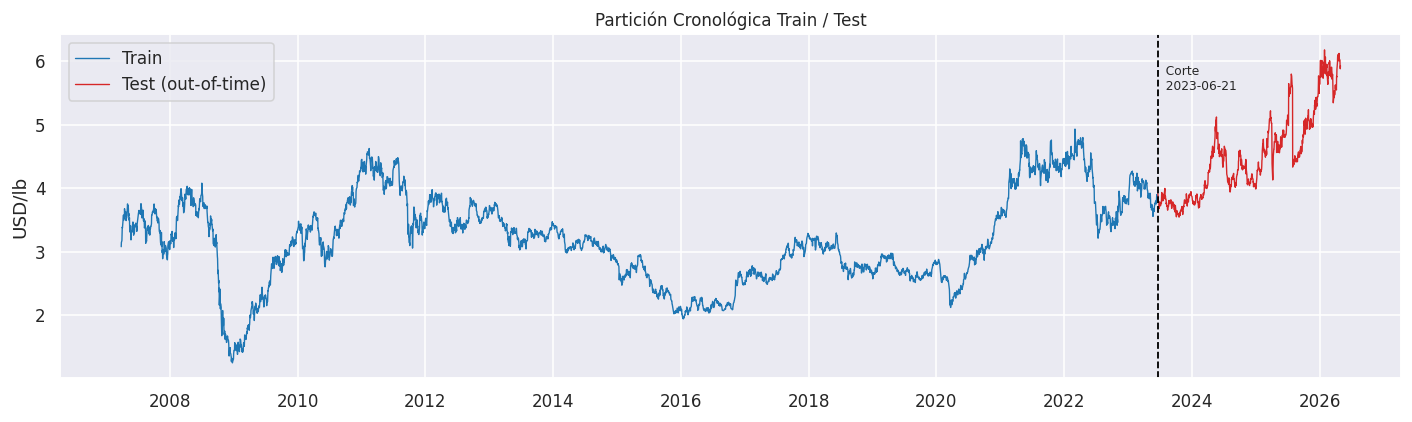

In [6]:
# ── Corte cronológico 85/15 ────────────────────────────────────────────────────
n = len(feat)
split_idx = int(n * TRAIN_RATIO)
split_date = feat.index[split_idx]

train = feat.iloc[:split_idx].copy()
test  = feat.iloc[split_idx:].copy()

print(f'Fecha de corte Train/Test : {split_date.date()}')
print(f'Train : {len(train):,} observaciones  ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Test  : {len(test):,}  observaciones  ({test.index[0].date()}  → {test.index[-1].date()})')
print(f'Ratio efectivo            : {len(train)/n:.1%} / {len(test)/n:.1%}')

# ── Visualización de la partición ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train['HG_close'], color='#1f77b4', linewidth=0.9, label='Train')
ax.plot(test['HG_close'],  color='#d62728', linewidth=0.9, label='Test (out-of-time)')
ax.axvline(split_date, color='black', linestyle='--', linewidth=1.2)
ax.text(split_date, float(feat['HG_close'].max()) * 0.9,
        f'  Corte\n  {split_date.date()}', fontsize=8)
ax.set_title('Partición Cronológica Train / Test', fontsize=11)
ax.set_ylabel('USD/lb')
ax.legend()
plt.tight_layout()
plt.savefig('output/08_train_test_split.png', bbox_inches='tight')
plt.show()

## 6. Escalado MinMaxScaler
El LSTM requiere features normalizadas en [0,1]. **Crítico:** el scaler se ajusta (`fit`) solo sobre Train y se aplica (`transform`) sobre Train y Test por separado, evitando data leakage.

In [7]:
# ── Escalado para LSTM (solo features de precio/lag) ─────────────────────────
# Columnas a escalar: precio y lags (los log-retornos ya están en escala pequeña)
cols_lstm = ['HG_close', 'UUP_close'] + \
            [f'HG_lag{l}' for l in [1,2,3,5,10]] + \
            [f'UUP_lag{l}' for l in [1,2,3,5,10]] + \
            ['HG_vol20']

scaler = MinMaxScaler(feature_range=(0, 1))

# fit SOLO sobre train — esta es la regla clave para evitar leakage
scaler.fit(train[cols_lstm])

train_scaled = train.copy()
test_scaled  = test.copy()
train_scaled[cols_lstm] = scaler.transform(train[cols_lstm])
test_scaled[cols_lstm]  = scaler.transform(test[cols_lstm])

print('Escalado completado. Rango train tras escalar:')
print(train_scaled[cols_lstm].agg(['min','max']).T)

Escalado completado. Rango train tras escalar:
           min  max
HG_close   0.0  1.0
UUP_close  0.0  1.0
HG_lag1    0.0  1.0
HG_lag2    0.0  1.0
HG_lag3    0.0  1.0
HG_lag5    0.0  1.0
HG_lag10   0.0  1.0
UUP_lag1   0.0  1.0
UUP_lag2   0.0  1.0
UUP_lag3   0.0  1.0
UUP_lag5   0.0  1.0
UUP_lag10  0.0  1.0
HG_vol20   0.0  1.0


## 7. Exportar Artefactos

In [8]:
# ── Guardar datasets y scaler ─────────────────────────────────────────────────
# Datos en escala original (para modelos estadísticos SARIMAX, Prophet, GARCH)
train.to_csv('data/train_raw.csv')
test.to_csv('data/test_raw.csv')

# Datos escalados (para LSTM)
train_scaled.to_csv('data/train_scaled.csv')
test_scaled.to_csv('data/test_scaled.csv')

# Scaler ajustado (necesario para invertir la normalización en Fase 3)
joblib.dump(scaler, 'data/minmax_scaler.pkl')

# Fecha de corte para referencia en fases siguientes
with open('data/split_date.txt', 'w') as f:
    f.write(str(split_date.date()))

print('Artefactos exportados:')
for fname in ['train_raw.csv','test_raw.csv','train_scaled.csv',
              'test_scaled.csv','minmax_scaler.pkl','split_date.txt']:
    size_kb = os.path.getsize(f'data/{fname}') / 1024
    print(f'  data/{fname:<25} {size_kb:.1f} KB')

Artefactos exportados:
  data/train_raw.csv             1177.1 KB
  data/test_raw.csv              206.3 KB
  data/train_scaled.csv          1215.8 KB
  data/test_scaled.csv           210.8 KB
  data/minmax_scaler.pkl         1.5 KB
  data/split_date.txt            0.0 KB


## Conclusiones de la Fase 2

| Decisión | Justificación |
|---|---|
| **Proxy dólar = UUP** | Activo líquido que cotiza en USD, correlación negativa con cobre confirmada |
| **Forward-fill limit=1** | Rellena un día hábil de gap (festivos locales) sin propagar datos durante vacíos largos |
| **Inicio efectivo = 2007** | Primera cotización disponible de UUP |
| **Corte Train/Test = 85/15** | Maximiza datos de entrenamiento manteniendo un test out-of-time representativo |
| **Scaler fit solo en Train** | Evita que el rango del test set contamine la normalización (data leakage) |
| **Log-retornos sin escalar** | Ya están en rango pequeño; el GARCH los necesita en escala original |

Los artefactos generados (`train_raw.csv`, `test_raw.csv`, `minmax_scaler.pkl`) son la entrada directa para las Fases 3, 4 y 5.